In [31]:
from simpleNN import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

This is just for the sake of testing, I will generate random numbers to serve as data and see how the neural net trains. However, before everything, I will decide the architecture and randomly generate the parameters in the weight matrices and bias vectors.

Architecture:

input vector:13x1 -> 

Hidden Layer 1 (A1:16x13, a1:16x1, sigma = ReLU) -> 

Hidden Layer 2 (A2:8x16, a2:8x1, sigma = ReLU) -> 

Output Layer(A3:1x8, a3:1x1, sigma = sigmoid)

In [50]:
# Initializing random parameters in weight matrices
np.random.seed(50)
A1 = np.random.randn(16, 19)
A2 = np.random.randn(8, 16)
A3 = np.random.randn(1, 8)

A = [A1, A2, A3]

# Initializing zero vectors in bias vectors
a1 = np.zeros(16)
a2 = np.zeros(8)
a3 = np.zeros(1)

a = [a1, a2, a3]

# Random inputs and assume an output of 1
features = np.random.randn(19)
y = np.array([1.0])

Here is a test of the forwardprop() function, note that this testing code is only reproducible since the random parameters and data are generated from a set seed.

In [51]:
preacts, activations, y_hat = forwardprop(features, A, a)
print(f"y_hat: {y_hat}")
print(preacts)
print(f"preacts length: {len(preacts)}")
print(activations)
print(f"activations length: {len(activations)}")

y_hat: [0.5]
[array([ 5.77256048, -6.35384526,  3.20208107, -0.03723207,  3.11154785,
        2.767515  ,  6.58567357, -6.90987365,  6.75630296, -0.70891599,
        0.26929125,  5.88605767,  2.41311878,  5.10726724, -4.84245225,
        5.88585702]), array([-21.62467008,  -8.4286005 , -12.13713808,  -3.48951236,
        -2.41186093,  -6.04119885, -20.02137678, -29.71634238]), array([0.])]
preacts length: 3
[array([-0.2546721 ,  0.19917438, -2.53004438, -0.67761295, -0.80183918,
       -1.88500871, -0.15086424, -0.05446797, -0.88571798, -0.12239577,
       -0.35340969, -2.24934842, -1.4162453 ,  0.14208669, -0.58796602,
        0.8766029 ,  0.94420405, -0.37636415, -0.26981292]), array([5.77256048, 0.        , 3.20208107, 0.        , 3.11154785,
       2.767515  , 6.58567357, 0.        , 6.75630296, 0.        ,
       0.26929125, 5.88605767, 2.41311878, 5.10726724, 0.        ,
       5.88585702]), array([0., 0., 0., 0., 0., 0., 0., 0.]), array([0.5])]
activations length: 4


Now to test the full functionality of the neural network, and arguably the most important part. This is a plot of the losses/error incurred on the neural net with 500 epochs and a learning rate eta of 0.001:

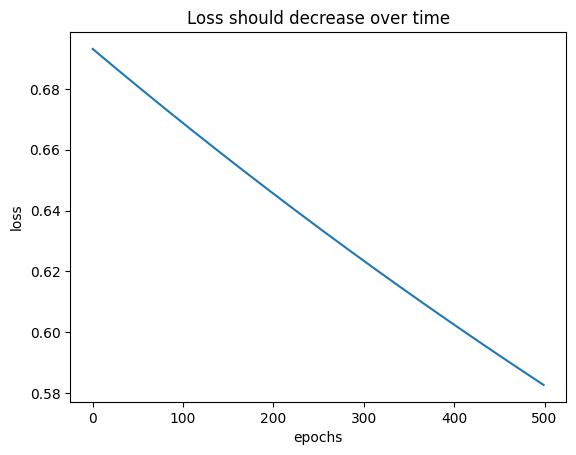

In [52]:
losses = []
epochs = 500
for i in range(epochs):
    preacts, activations, y_hat = forwardprop(features, A, a)
    l = bce_loss(y, y_hat)
    losses.append(l)
    # Updating the parameters with learning rate eta = 0.001
    backwardprop(y, y_hat, preacts, activations, A, a, 0.001)

# Plotting losses/errors
plt.plot(losses)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Loss should decrease over time")
plt.show()

Now, to actually train the framework, I want to use the UCI heart diease dataset and try to use the 13 current features within it to predict the "target" column using classification. 

In order to pass a numeric vector through the neural network, I need to convert all categorical variables into indicator variables. Fortunately, that can be completed through some data wrangling.

In [19]:
# Reading the data
heart_disease = pd.read_csv("HeartDiseaseTrain-Test.csv")

# Data wrangling
flourosopy_map = {"Zero": 0, "One": 1, "Two": 2, "Three": 3, "Four": 4}

hd_wrangled = heart_disease.assign(
    exercise_induced_angina = np.where(heart_disease["exercise_induced_angina"] == "Yes", 1, 0),
    fasting_blood_sugar = np.where(heart_disease["fasting_blood_sugar"] == "Greater than 120 mg/ml", 1, 0),
    ismale = np.where(heart_disease["sex"] == "Male", 1, 0),
    vessels_colored_by_flourosopy = heart_disease["vessels_colored_by_flourosopy"].map(flourosopy_map),

    # rest_ecg: Normal is the base case
    ST_T_wave_abnorm = np.where(heart_disease["rest_ecg"] == "ST-T wave abnormality", 1, 0),
    Left_vent_hyper = np.where(heart_disease["rest_ecg"] == "Left ventricular hypertrophy", 1, 0),

    # chest_pain_type: Typical angina is the base case
    Asymptomatic = np.where(heart_disease["chest_pain_type"] == "Asymptomatic", 1, 0),
    Atypical_angina = np.where(heart_disease["chest_pain_type"] == "Atypical angina", 1, 0),
    Non_anginal = np.where(heart_disease["chest_pain_type"] == "Non-anginal pain", 1, 0),

    # slope: Flat is the base case
    Downslope = np.where(heart_disease["slope"] == "Downsloping", 1, 0),
    Upslope = np.where(heart_disease["slope"] == "Upsloping", 1, 0),

    # thalassemia: Normal is the base case
    Fixed_defect = np.where(heart_disease["thalassemia"] == "Fixed Defect", 1, 0),
    No = np.where(heart_disease["thalassemia"] == "No", 1, 0),
    Reverse_defect = np.where(heart_disease["thalassemia"] == "Reversable Defect", 1, 0)
).drop(
    ["sex", "rest_ecg", "chest_pain_type", "slope", "thalassemia"], axis = 1
)
    
features = hd_wrangled.drop("target", axis = 1).values
y = hd_wrangled["target"].values


In [20]:
# Splitting the data
np.random.seed(123)
nrows = len(features)
indices = np.random.permutation(nrows)
split = int(0.8 * nrows) # 80-20 split
train_idx = indices[:split]
test_idx = indices[split:]

features_train = features[train_idx]
y_train = y[train_idx]
features_test = features[test_idx]
y_test = y[test_idx]

# Standardizing the features data to get mean of 0 and sd of 1
features_train_mean = np.mean(features_train, axis = 0)
features_train_sd = np.std(features_train, axis = 0)
features_train_scaled = (features_train - features_train_mean) / features_train_sd
features_test_scaled = (features_test - features_train_mean) / features_train_sd


Finally, after the fun work of data wrangling and getting all the necessary training and testing data in shape. We can input the training data into the neural network, the input vector will have size 19, 100 epochs, and with a learning rate eta of 0.0001.

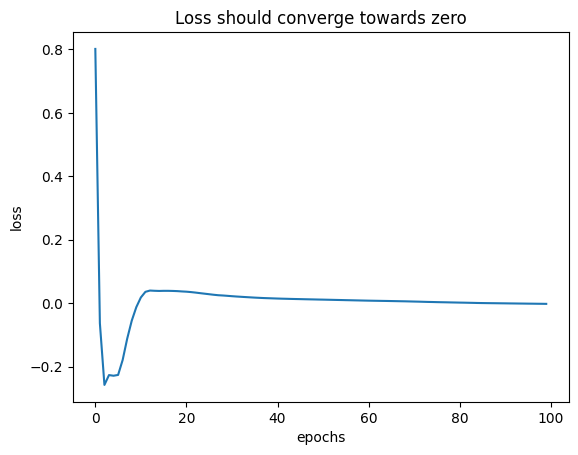

In [21]:
# Initializing random parameters in weight matrices
np.random.seed(42)
A1 = np.random.randn(16, 19)
A2 = np.random.randn(8, 16)
A3 = np.random.randn(1, 8)

A = [A1, A2, A3]

# Initializing zero vectors in bias vectors
a1 = np.zeros(16)
a2 = np.zeros(8)
a3 = np.zeros(1)

a = [a1, a2, a3]

# Training the neural net
epochs = 100
errors = []

for epoch in range(epochs):
    epoch_loss = []
    for i in range(len(features_train_scaled)):
        inputv = features_train_scaled[i]
        y = y_train[i]
        preacts, activations, y_hat = forwardprop(inputv, A, a)
        l = bce_loss(y, y_hat)
        epoch_loss.append(l)
        backwardprop(y, y_hat, preacts, activations, A, a, 0.0001)
    errors.append(np.mean(epoch_loss))  # average loss per epoch

plt.plot(errors)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Loss should converge towards zero")
plt.show()

In [22]:
for i in range(len(features_test_scaled)):
    errors1 = []
    inputv = features_test_scaled[i]
    y = y_test[i]
    preacts, activations, y_hat = forwardprop(inputv, A, a)
    l = bce_loss(y, y_hat)
    errors1.append(l)

print(np.mean(errors))

0.0059529297203200614


An mean error of around 0.006 is very decent for a neural network frame work that is only 2 layers deep, limited amount of neurons, and trained on only 820 points of data. 

In [23]:
test = np.array([ 0.43, -1.12, 0.07, 0.55, -0.88, 1.02, -0.34, 0.19, 0.76, -0.51, 0.11, -1.44, 0.63, -0.29, 0.92, -0.14, 0.38, -0.73, 1.27])
_, _, output = forwardprop(test, A, a)
print(output[-1])

0.062255083087991464
